# Phonemic Entropy Flow from Pediatric PPGs

**Research question:** Can phoneme-probability dynamics from PPG matrices capture differences in pediatric voice/speech-related medical conditions?

This notebook builds a cleaned analysis pipeline:

1. Load Phonetic PosteriorGram (PPG) features.
2. Convert each raw PPG into a `(time, phoneme)` matrix.
3. Compute the raw phonemic entropy curve `H(t)`.
4. Compute entropy flow `dH/dt`.
5. Extract interpretable per-recording features.
6. Focus on prolonged phonation (`long-sounds-*`) tasks.
7. Aggregate repeated prolonged-phonation trials per participant.
8. Merge with cleaned medical-condition labels.
9. Run PCA and UMAP, then color embeddings by medical conditions and feature values.

> Note: This notebook intentionally uses **raw entropy** rather than smoothed entropy, because sharp transitions and near-zero values may reflect real phoneme/consonant structure rather than noise.

## 0. Imports and configuration

Run this cell first. If `umap` is missing, install it with:

```bash
conda install -c conda-forge umap-learn
# or
pip install umap-learn
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# UMAP is optional until the UMAP section.
# If this import fails, install umap-learn.
try:
    import umap
    HAS_UMAP = True
except ModuleNotFoundError:
    HAS_UMAP = False
    print("UMAP is not installed. Install with: conda install -c conda-forge umap-learn")

sns.set_context("notebook")
RANDOM_STATE = 42

## 1. Load PPG data

The PPG table is recording-level. Each row corresponds to one participant, one session, and one acoustic task.

Expected important columns:

- `participant_id`
- `session_id`
- `task_name`
- `ppgs`
- `n_frames`

The raw `ppgs` object is stored as 40 phoneme-specific time series. We will reshape it into a matrix where rows are time frames and columns are phoneme probabilities.

In [2]:
PPG_PATH = "../features/ppgs.parquet"

df_ppg = pd.read_parquet(PPG_PATH)

print("PPG shape:", df_ppg.shape)
display(df_ppg.head())
print(df_ppg.columns)

PPG shape: (22620, 5)


,participant_id,session_id,task_name,ppgs,n_frames
0,010729,218720d1,naming-animals-1,"[[6e-08, 6e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1250
1,010729,218720d1,naming-food-1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1079
2,010729,218720d1,passage-1,"[[2.4e-07, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",341
3,010729,218720d1,passage-10,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",584
4,010729,218720d1,passage-11,"[[4e-07, 4e-07, 3.6e-07, 3e-07, 2.4e-07, 2.4e-...",746


Index(['participant_id', 'session_id', 'task_name', 'ppgs', 'n_frames'], dtype='str')


## 2. Helper functions

### Why reshaping is needed

The raw PPG format is usually shaped like:

```text
40 phonemes × T time frames
```

For entropy, we need each time frame to be one probability distribution over phonemes:

```text
T time frames × 40 phonemes
```

So `load_ppg_matrix()` stacks the 40 phoneme streams and transposes the matrix.

In [3]:
def load_ppg_matrix(ppg_raw):
    """
    Convert raw PPG data into a (T, 40) matrix.

    Parameters
    ----------
    ppg_raw : array-like of length 40
        Each element is a 1D array of length T representing the probability
        of one phoneme over time.

    Returns
    -------
    ppg : np.ndarray of shape (T, 40)
        Each row is one time frame. Each row should sum to approximately 1.
    """
    ppg = np.vstack(ppg_raw)   # (40, T)
    ppg = ppg.T                # (T, 40)
    return np.asarray(ppg, dtype=np.float32)


def compute_entropy_curve(ppg, eps=1e-8):
    """
    Compute raw phonemic entropy H(t) for each time frame.

    Entropy is low when the PPG is confident about one phoneme and high when
    probability mass is spread across many phonemes.

    Parameters
    ----------
    ppg : np.ndarray of shape (T, 40)
        Rows are time frames and columns are phoneme probabilities.
    eps : float
        Small constant to avoid log(0).

    Returns
    -------
    H : np.ndarray of shape (T,)
        Raw entropy curve over time.
    """
    ppg = np.asarray(ppg, dtype=np.float32)
    H = -np.sum(ppg * np.log(ppg + eps), axis=1)
    return H.astype(np.float32)


def extract_entropy_features(ppg_raw):
    """
    Extract interpretable entropy-flow features from one raw PPG recording.

    Output features are recording-level summaries:
    - mean_entropy: average uncertainty across the recording
    - std_entropy: variability of uncertainty
    - mean_abs_dH_dt: average magnitude of entropy change
    - std_dH_dt: variability/instability of entropy flow
    - max_dH_dt: sharpest increase in uncertainty
    - min_dH_dt: sharpest decrease in uncertainty
    - entropy_range: max entropy - min entropy
    - n_entropy_peaks: number of local maxima in entropy
    - transition_density: entropy peaks per frame
    - duration: number of frames
    """
    ppg = load_ppg_matrix(ppg_raw)
    H = compute_entropy_curve(ppg)
    dH_dt = np.gradient(H)

    peaks, _ = find_peaks(H)

    duration = len(H)
    return {
        "mean_entropy": float(np.mean(H)),
        "std_entropy": float(np.std(H)),
        "mean_abs_dH_dt": float(np.mean(np.abs(dH_dt))),
        "std_dH_dt": float(np.std(dH_dt)),
        "max_dH_dt": float(np.max(dH_dt)),
        "min_dH_dt": float(np.min(dH_dt)),
        "entropy_range": float(np.max(H) - np.min(H)),
        "n_entropy_peaks": int(len(peaks)),
        "transition_density": float(len(peaks) / duration) if duration > 0 else np.nan,
        "duration": int(duration),
    }

## 3. Sanity check on one recording

Before extracting features for the whole dataset, inspect one PPG matrix and confirm that each time frame is a valid probability distribution.

In [4]:
ppg_test = load_ppg_matrix(df_ppg.iloc[0]["ppgs"])

print("PPG test shape:", ppg_test.shape)
print("One frame shape:", ppg_test[0].shape)
print("Sum of first frame:", ppg_test[0].sum())

PPG test shape: (1250, 40)
One frame shape: (40,)
Sum of first frame: 1.0001401


## 4. Visualize entropy and entropy flow for one recording

`H(t)` measures frame-by-frame phoneme uncertainty.

`dH/dt` measures how quickly that uncertainty changes. Positive spikes indicate entropy rising into a transition; negative spikes indicate entropy falling as the model settles into a phoneme.

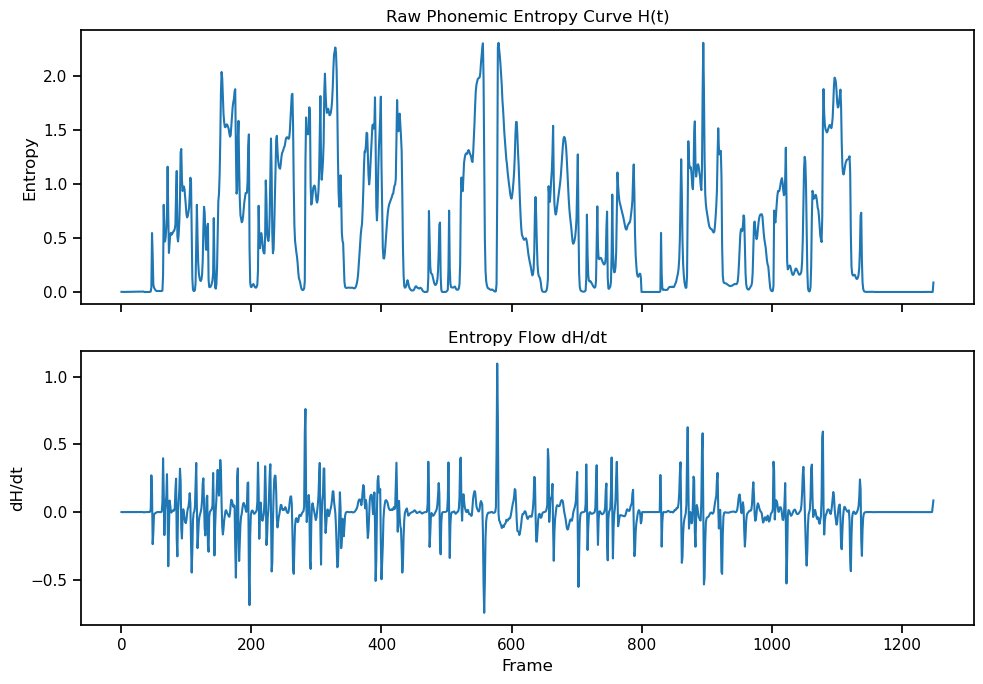

{'mean_entropy': 0.5839421153068542, 'std_entropy': 0.5973964929580688, 'mean_abs_dH_dt': 0.07883849740028381, 'std_dH_dt': 0.14370958507061005, 'max_dH_dt': 1.0960302352905273, 'min_dH_dt': -0.7434139251708984, 'entropy_range': 2.31076717376709, 'n_entropy_peaks': 129, 'transition_density': 0.1032, 'duration': 1250}


In [5]:
H_test = compute_entropy_curve(ppg_test)
dH_dt_test = np.gradient(H_test)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(H_test)
axes[0].set_title("Raw Phonemic Entropy Curve H(t)")
axes[0].set_ylabel("Entropy")

axes[1].plot(dH_dt_test)
axes[1].set_title("Entropy Flow dH/dt")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("dH/dt")

plt.tight_layout()
plt.show()

print(extract_entropy_features(df_ppg.iloc[0]["ppgs"]))

## 5. Extract entropy-flow features for all recordings

This creates `df_features`, where each row is one recording/task for one participant.

In [6]:
feature_rows = []

for _, row in df_ppg.iterrows():
    feats = extract_entropy_features(row["ppgs"])
    feats["participant_id"] = row["participant_id"]
    feats["session_id"] = row["session_id"]
    feats["task_name"] = row["task_name"]
    feature_rows.append(feats)

df_features = pd.DataFrame(feature_rows)

print("Feature table shape:", df_features.shape)
display(df_features.head())

Feature table shape: (22620, 13)


,mean_entropy,std_entropy,mean_abs_dH_dt,std_dH_dt,max_dH_dt,min_dH_dt,entropy_range,n_entropy_peaks,transition_density,duration,participant_id,session_id,task_name
0,0.583942,0.597396,0.078838,0.143710,1.096030,-0.743414,2.310767,129,0.103200,1250,010729,218720d1,naming-animals-1
1,0.540543,0.556287,0.082587,0.141336,0.694280,-0.689321,2.253652,109,0.101019,1079,010729,218720d1,naming-food-1
2,0.388438,0.421150,0.108178,0.166413,0.575579,-0.564967,1.558551,51,0.149560,341,010729,218720d1,passage-1
3,0.456186,0.509727,0.104594,0.173336,0.867250,-0.645216,2.212766,81,0.138699,584,010729,218720d1,passage-10
4,0.318197,0.408854,0.098809,0.163794,0.786221,-0.732434,1.993775,101,0.135389,746,010729,218720d1,passage-11


## 6. Quick task-level exploration

This checks whether different acoustic tasks naturally have different entropy-flow profiles.

,mean_entropy,std_entropy,mean_abs_dH_dt,std_dH_dt,max_dH_dt,min_dH_dt,entropy_range,n_entropy_peaks,transition_density,duration
task_name,,,,,,,,,,
123s-1,0.581275,0.556823,0.080494,0.140004,0.885170,-0.567458,2.305468,118.000000,0.103937,1137.000000
days-1,0.540332,0.609567,0.067916,0.132228,0.757078,-0.688448,2.431188,101.500000,0.109157,934.000000
long-sounds-1,0.708869,0.647625,0.033719,0.080298,0.913518,-0.518188,2.230342,107.650307,0.099029,1085.306748
long-sounds-2,0.619970,0.615209,0.031292,0.076794,0.833332,-0.532046,2.143051,100.619355,0.097455,1032.103226
long-sounds-3,0.655789,0.609095,0.032145,0.074705,0.729400,-0.529711,2.102656,105.833333,0.102908,1026.416667
long-sounds-4,0.406665,0.426912,0.030608,0.074304,0.786734,-0.489297,1.938960,90.333333,0.097495,948.333333
long-sounds-5,0.965702,0.871949,0.024128,0.065531,0.870356,-0.880920,2.466330,167.000000,0.106099,1574.000000
long-sounds-6,0.583977,0.631211,0.036618,0.090182,0.974791,-0.866095,2.359602,106.000000,0.097876,1083.000000
months-1,0.711136,0.584265,0.096533,0.155424,0.710940,-0.619984,2.338720,117.000000,0.121369,964.000000


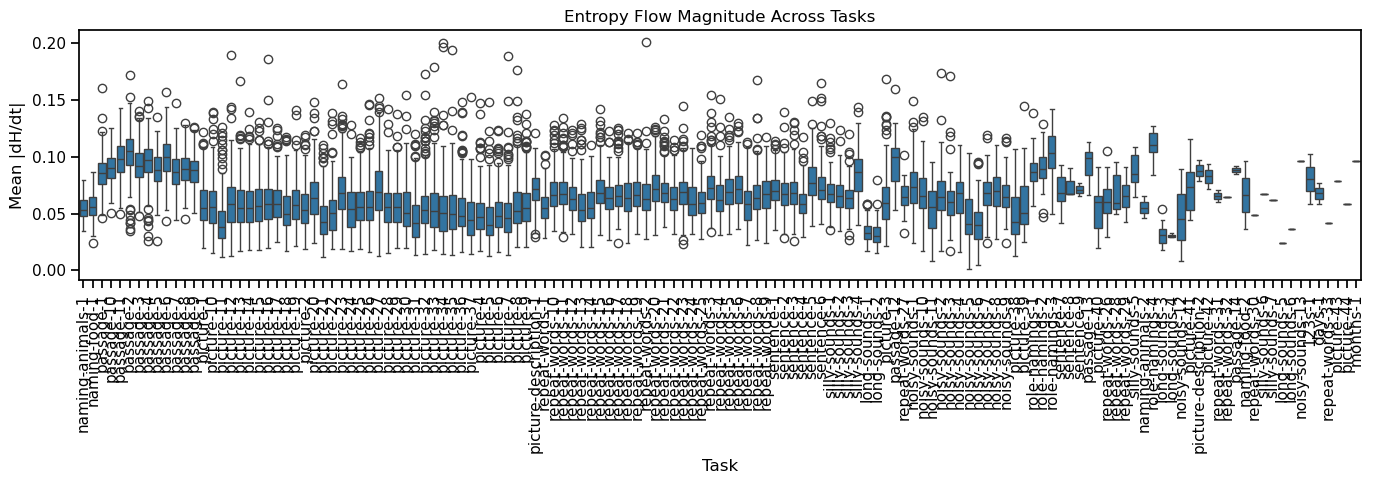

In [7]:
base_feature_cols = [
    "mean_entropy",
    "std_entropy",
    "mean_abs_dH_dt",
    "std_dH_dt",
    "max_dH_dt",
    "min_dH_dt",
    "entropy_range",
    "n_entropy_peaks",
    "transition_density",
    "duration",
]

df_task_summary = df_features.groupby("task_name")[base_feature_cols].mean(numeric_only=True)
display(df_task_summary.head(20))

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_features, x="task_name", y="mean_abs_dH_dt")
plt.xticks(rotation=90)
plt.title("Entropy Flow Magnitude Across Tasks")
plt.xlabel("Task")
plt.ylabel("Mean |dH/dt|")
plt.tight_layout()
plt.show()

## 7. Focus on prolonged phonation (`long-sounds-*`)

For this analysis, we focus on prolonged phonation tasks because they are repeated versions of a similar behavior. This makes aggregation more meaningful.

Each participant may have multiple `long-sounds-*` trials. We aggregate features across those repeated trials using both mean and standard deviation:

- Mean = typical prolonged-phonation behavior
- Std = consistency across repeated trials

In [8]:
df_long = df_features[df_features["task_name"].str.contains("long-sounds", na=False)].copy()

print("Long-sounds recordings:", df_long.shape)
print("Long-sounds tasks:", sorted(df_long["task_name"].unique()))

df_long_participant = (
    df_long
    .groupby("participant_id")[base_feature_cols]
    .agg(["mean", "std"])
)

df_long_participant.columns = [f"{col}_{stat}" for col, stat in df_long_participant.columns]
df_long_participant = df_long_participant.reset_index()

print("Participant-level long-sounds table:", df_long_participant.shape)
display(df_long_participant.head())

Long-sounds recordings: (335, 13)
Long-sounds tasks: ['long-sounds-1', 'long-sounds-2', 'long-sounds-3', 'long-sounds-4', 'long-sounds-5', 'long-sounds-6']
Participant-level long-sounds table: (184, 21)


,participant_id,mean_entropy_mean,mean_entropy_std,std_entropy_mean,std_entropy_std,mean_abs_dH_dt_mean,mean_abs_dH_dt_std,std_dH_dt_mean,std_dH_dt_std,max_dH_dt_mean,...,min_dH_dt_mean,min_dH_dt_std,entropy_range_mean,entropy_range_std,n_entropy_peaks_mean,n_entropy_peaks_std,transition_density_mean,transition_density_std,duration_mean,duration_std
0,013531,0.658900,0.000359,0.662842,0.079181,0.027708,0.004191,0.074368,0.025632,0.773679,...,-0.554021,0.331073,2.031921,0.157191,113.5,37.476659,0.103912,0.003274,1098.5,395.272691
1,041673,0.681430,0.003047,0.703025,0.022683,0.034100,0.001953,0.078827,0.004645,0.757025,...,-0.469716,0.068867,2.337299,0.053898,107.0,22.627417,0.091445,0.007107,1164.0,156.977705
2,044052,0.625929,NaN,0.643395,NaN,0.022280,NaN,0.056818,NaN,0.821733,...,-0.423800,NaN,2.225060,NaN,206.0,NaN,0.104304,NaN,1975.0,NaN
3,047346,0.799786,NaN,0.796650,NaN,0.031736,NaN,0.071525,NaN,0.868955,...,-0.435116,NaN,2.352373,NaN,109.0,NaN,0.101019,NaN,1079.0,NaN
4,047894,0.847464,NaN,0.704802,NaN,0.032714,NaN,0.065200,NaN,1.116390,...,-0.310331,NaN,2.360381,NaN,162.0,NaN,0.094461,NaN,1715.0,NaN


## 8. Load and clean medical-condition labels

Medical labels are participant-level. We create clean binary variables for the conditions most relevant to speech and airway/sleep.

Important detail: `peds_mc_snoring_apnea` is a multi-label text column, not a simple Yes/No field. We parse it into separate binary indicators.

In [10]:
LABEL_PATH = "../phenotype/pediatric/pediatric_medical_conditions.tsv"

df_labels = pd.read_csv(LABEL_PATH, sep="	")

print("Raw labels shape:", df_labels.shape)
display(df_labels.head())
print(df_labels.columns)

print("Raw peds_mc_snoring_apnea value counts:")
display(df_labels["peds_mc_snoring_apnea"].value_counts(dropna=False).head(20))

Raw labels shape: (305, 50)


,participant_id,peds_mc_a_therapy,peds_mc_adenoidectomy,peds_mc_allergies,peds_mc_breathing_conditions,peds_mc_chronic_medical_condition,peds_mc_completed_at,peds_mc_conditions,peds_mc_dif_swallowing,peds_mc_duration,...,peds_mc_snoring_apnea,peds_mc_snoring_apnea_had_sleep_study_oahi,peds_mc_started_at,peds_mc_stridor,peds_mc_surgery_t_vc_a,peds_mc_tonsillectomy,peds_mc_v_dis,peds_mc_voice_disorders,peds_mc_conditions___other,peds_mc_psych_disorders___other
0,512342,Yes,No,No,NaN,No,2025-06-04T16:09:25.044Z,NaN,No,8.0,...,NaN,NaN,2025-06-04T15:59:32.036Z,No,No,No,Yes,NaN,1.0,1.0
1,458172,No,No,Yes,NaN,No,2025-06-04T15:22:27.181Z,NaN,No,619.0,...,NaN,NaN,2025-06-04T15:17:50.562Z,No,No,No,No,NaN,1.0,1.0
2,822069,No,No,No,NaN,No,2025-06-03T14:35:36.004Z,NaN,No,133.0,...,gasping,NaN,2025-06-03T14:30:42.871Z,No,No,No,No,NaN,1.0,1.0
3,971270,No,No,Yes,NaN,No,2025-06-04T17:01:11.940Z,NaN,No,719.0,...,NaN,NaN,2025-06-04T16:56:00.221Z,No,No,No,No,NaN,1.0,1.0
4,216464,No,No,No,NaN,No,2025-06-04T18:47:58.445Z,NaN,No,830.0,...,NaN,NaN,2025-06-04T18:40:02.615Z,No,No,No,No,NaN,1.0,1.0


Index(['participant_id', 'peds_mc_a_therapy', 'peds_mc_adenoidectomy',
       'peds_mc_allergies', 'peds_mc_breathing_conditions',
       'peds_mc_chronic_medical_condition', 'peds_mc_completed_at',
       'peds_mc_conditions', 'peds_mc_dif_swallowing', 'peds_mc_duration',
       'peds_mc_ear_inf_ant_py', 'peds_mc_epistaxis', 'peds_mc_etp',
       'peds_mc_eval_voice_swal_c', 'peds_mc_fr_inf_tons', 'peds_mc_fr_v_f',
       'peds_mc_ft', 'peds_mc_genetic_syndromes', 'peds_mc_hearing_loss',
       'peds_mc_hl', 'peds_mc_hospitalized', 'peds_mc_hw_voice_2_w',
       'peds_mc_l2w', 'peds_mc_lingual_tonsillectomy', 'peds_mc_meds',
       'peds_mc_nasal_fractures',
       'peds_mc_neck_mass_branchial_cleft_cyst_surgery',
       'peds_mc_neck_mass_dermoid_cyst_surgery',
       'peds_mc_neck_mass_enlarged_lymph_node_surgery',
       'peds_mc_neck_mass_hyroid_nodule_or_cancer_surgery',
       'peds_mc_neck_mass_other',
       'peds_mc_neck_mass_thyroglossal_duct_cyst_surgery',
       'peds_mc_n

peds_mc_snoring_apnea
NaN                                                  222
gasping                                               62
gasping, obstructive sleep apnea                       7
had sleep study                                        5
gasping, obstructive sleep apnea, had sleep study      4
gasping, had sleep study                               2
obstructive sleep apnea                                2
obstructive sleep apnea, had sleep study               1
Name: count, dtype: int64

In [11]:
# Build clean participant-level label table from medical conditions.
df_labels_clean = df_labels.copy()
df_labels_clean["participant_id"] = df_labels_clean["participant_id"].astype(str)

# Standard Yes/No labels.
df_labels_clean["voice_disorder"] = (df_labels_clean["peds_mc_v_dis"] == "Yes").astype(int)
df_labels_clean["speech_therapy"] = (df_labels_clean["peds_mc_a_therapy"] == "Yes").astype(int)
df_labels_clean["hoarseness"] = (df_labels_clean["peds_mc_hw_voice_2_w"] == "Yes").astype(int)

# Parse multi-label snoring/apnea text column.
snore_text = df_labels_clean["peds_mc_snoring_apnea"].fillna("").astype(str).str.lower()

df_labels_clean["snoring_or_gasping"] = snore_text.str.contains("snor|gasp", regex=True).astype(int)
df_labels_clean["sleep_apnea"] = snore_text.str.contains("obstructive sleep apnea", regex=False).astype(int)
df_labels_clean["had_sleep_study"] = snore_text.str.contains("sleep study", regex=False).astype(int)

df_labels_clean["any_sleep_issue"] = (
    df_labels_clean["snoring_or_gasping"]
    | df_labels_clean["sleep_apnea"]
    | df_labels_clean["had_sleep_study"]
).astype(int)

label_cols = [
    "voice_disorder",
    "speech_therapy",
    "hoarseness",
    "snoring_or_gasping",
    "sleep_apnea",
    "had_sleep_study",
    "any_sleep_issue",
]

df_labels_clean = df_labels_clean[["participant_id"] + label_cols]

print("Clean label counts:")
display(df_labels_clean[label_cols].sum().sort_values(ascending=False))
display(df_labels_clean.head())

Clean label counts:


any_sleep_issue       83
snoring_or_gasping    75
speech_therapy        72
voice_disorder        31
sleep_apnea           14
hoarseness            13
had_sleep_study       12
dtype: int64

,participant_id,voice_disorder,speech_therapy,hoarseness,snoring_or_gasping,sleep_apnea,had_sleep_study,any_sleep_issue
0,512342,1,1,0,0,0,0,0
1,458172,0,0,0,0,0,0,0
2,822069,0,0,0,1,0,0,1
3,971270,0,0,0,0,0,0,0
4,216464,0,0,0,0,0,0,0


## 9. Merge prolonged-phonation features with labels

The merged table is participant-level:

- One row = one participant
- Features = mean/std summaries of prolonged phonation entropy-flow features
- Labels = cleaned medical-condition indicators

In [ ]:
df_long_participant["participant_id"] = df_long_participant["participant_id"].astype(str)

df_merged = df_long_participant.merge(df_labels_clean, on="participant_id", how="inner")

print("Merged shape:", df_merged.shape)
print("Merged label counts:")
display(df_merged[label_cols].sum().sort_values(ascending=False))
display(df_merged.head())